https://doi.org/10.3389/fmolb.2020.00183

In [1]:
import os
os.environ["PYTHONWARNINGS"] = "ignore"

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import cv2
import glob
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models

from scipy.stats import pearsonr
from torch.autograd import Variable
from tqdm import tqdm
from torchvision import transforms

In [4]:
class Net(nn.Module):
    def __init__(self , pretrained=True):
        super(Net, self).__init__()
        #Remove the last two layers of the model
        model = models.resnet18(pretrained=pretrained)
        self.resnet_layer = nn.Sequential(*list(model.children())[:-2])
        self.fc = nn.Linear(512*2*2, 3)
        
    def forward(self, x):
        x = self.resnet_layer(x)
        x = x.view(x.size(0), -1) 
        x = self.fc(x)
        
        return x

In [5]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
trained_model = torch.load("data/resnet18_0.9326.model", weights_only=False, map_location="cuda:0")
trained_model.eval()
trained_model = trained_model.to(device)

convLayers = nn.Sequential(*list(trained_model.children())[:-1])

conv_fc = nn.Conv2d(in_channels=512, out_channels=3, kernel_size=2, stride=1)
conv_fc.load_state_dict({"weight": trained_model.fc.state_dict()["weight"].view(3, 512, 2, 2), "bias": trained_model.fc.state_dict()["bias"]})
conv_fc = conv_fc.to(device)

In [6]:
slides = sorted(glob.glob("slides/*.png"))
slides = [slide.split("/")[-1].split(".")[0] for slide in slides]

In [7]:
for slide in slides:
    image = cv2.imread(f"slides/{slide}.png")
    resized_w = image.shape[1]
    resized_h = image.shape[0]
    # plt.imshow(image)

    sub_num = 1

    transformation = transforms.Compose(
        [
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ]
    )

    X_temp = None
    Y_temp = None

    with tqdm(total=sub_num * sub_num) as pbar:
        for y in range(sub_num):
            for x in range(sub_num):
                xs = int(resized_w * x / sub_num)
                ys = int(resized_h * y / sub_num)
                ws = int(resized_w / sub_num)
                hs = int(resized_h / sub_num)
                sub_image = image[ys : ys + hs, xs : xs + ws, :]
                _image_tensor = transformation(sub_image).float()
                image_tensor = _image_tensor.unsqueeze_(0)

                if torch.cuda.is_available():
                    image_tensor = image_tensor.to(device)

                inputs = Variable(image_tensor)
                with torch.no_grad():
                    output1 = convLayers(inputs)
                    _output2 = conv_fc(output1)
                    output2 = F.softmax(_output2, dim=1)

                if X_temp is not None:
                    X_temp = torch.cat([X_temp, output2], 3)
                else:
                    X_temp = output2
                pbar.update(1)

            if Y_temp is not None:
                Y_temp = torch.cat([Y_temp, X_temp], 2)
            else:
                Y_temp = X_temp
            X_temp = None

    _out = Y_temp.squeeze_(0).data.cpu().numpy()

    out_pos = _out.transpose((1, 2, 0))[:, :, 1]
    out_neg = _out.transpose((1, 2, 0))[:, :, 0]
    out_mask = _out.transpose((1, 2, 0))[:, :, 2] > 0.6
    color_out = np.zeros([_out.shape[1], _out.shape[2], 3], "uint8")

    thresh = 0.2
    # Negative/other regions: #6A5ACD (BGR: 205, 90, 106)
    color_out[:, :, 0][out_pos < out_neg] = 205
    color_out[:, :, 1][out_pos < out_neg] = 90
    color_out[:, :, 2][out_pos < out_neg] = 106

    # Ki67+ positive: #2FBF71 (BGR: 113, 191, 47)
    color_out[:, :, 0][out_pos > out_neg] = 113
    color_out[:, :, 1][out_pos > out_neg] = 191
    color_out[:, :, 2][out_pos > out_neg] = 47

    color_out[:, :, 0][out_mask] = 255
    color_out[:, :, 1][out_mask] = 255
    color_out[:, :, 2][out_mask] = 255

100%|██████████| 1/1 [00:00<00:00, 43.85it/s]


# 4. Calculate the statistical indexes of H&E stained ROIs

In [8]:
sub_num = 1

transformation = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def HE_calc(img_path):
    save_dir = "slides/outs/"
    img_name = os.path.basename(img_path)

    image = cv2.imread(img_path)
    resized_w = image.shape[1]
    resized_h = image.shape[0]

    X_temp = None
    Y_temp = None

    for y in range(sub_num):
        for x in range(sub_num):
            xs = int(resized_w*x/sub_num)
            ys = int(resized_h*y/sub_num)
            ws = int(resized_w/sub_num)
            hs = int(resized_h/sub_num)
            sub_image = image[ys:ys+hs, xs:xs+ws, :]
            _image_tensor = transformation(sub_image).float()
            image_tensor = _image_tensor.unsqueeze_(0)

            if torch.cuda.is_available():
                image_tensor = image_tensor.to(device)

            inputs = Variable(image_tensor)
            with torch.no_grad():
                output1 = convLayers(inputs)
                _output2 = conv_fc(output1)
                output2 = F.softmax(_output2, dim=1)

            if X_temp is not None:
                X_temp = torch.cat([X_temp,output2],3)
            else:
                X_temp = output2

        if Y_temp is not None:
            Y_temp = torch.cat([Y_temp,X_temp],2)
        else:
            Y_temp = X_temp
        X_temp = None
    
    _out = Y_temp.squeeze_(0).data.cpu().numpy().argmax(0)
    out = Y_temp.squeeze_(0).data.cpu().numpy()
    color_out = np.zeros([out.shape[1], out.shape[2], 3], "uint8")
    out_pos = out[1]
    out_neg = out[0]
    out_mask = out[2] > 0.6
    thresh = 0.3
    
    # Negative/other regions: #6A5ACD (BGR: 205, 90, 106)
    color_out[:,:,0][out_pos<thresh] = 205
    color_out[:,:,1][out_pos<thresh] = 90
    color_out[:,:,2][out_pos<thresh] = 106

    # Ki67+ positive: #2FBF71 (BGR: 113, 191, 47)
    color_out[:,:,0][out_pos>thresh] = 113
    color_out[:,:,1][out_pos>thresh] = 191
    color_out[:,:,2][out_pos>thresh] = 47

    color_out[:,:,0][out_mask] = 255
    color_out[:,:,1][out_mask] = 255
    color_out[:,:,2][out_mask] = 255
    
    name, ext = os.path.splitext(img_name)
    out_name = name + "_out.png"
    out_path = os.path.join(save_dir, out_name)
    cv2.imwrite(out_path, color_out)
    
    pos_res = (color_out[:,:,0] == 113).astype(np.uint8)
    pos_dense = np.average(pos_res)

    neg_res = (color_out[:,:,0] == 205).astype(np.uint8) 
    neg_dense = np.average(neg_res)

    pos_ratio = pos_dense / (pos_dense + neg_dense)
    
    return pos_dense, neg_dense, pos_ratio

In [9]:
HE_list = glob.glob("slides/*.png")

HE_list.sort()
HE_Dpos = []
HE_Dneg = []
HE_Rpos = []

with tqdm(total=len(HE_list)) as pbar:
    for img_path in HE_list:
        img_name = os.path.basename(img_path)
        pbar.set_description("processing %s" % img_name)
        pos_dense, neg_dense, pos_ratio = HE_calc(img_path)
        HE_Dpos.append(pos_dense)
        HE_Dneg.append(neg_dense)
        HE_Rpos.append(pos_ratio)
        pbar.update(1)

processing slide_7.png: 100%|██████████| 4/4 [00:00<00:00, 10.42it/s]


In [10]:
def IHC_calc(img_path):
    save_dir = "slides/outs/"
    img_name = os.path.basename(img_path)

    img = cv2.imread(img_path)
    color_out = np.zeros(list(img.shape), "uint8") + 255

    # negative mask and negative dense
    neg_lower = np.array([150,0,0])
    neg_upper = np.array([255,255,160])
    neg_mask = cv2.inRange(img,neg_lower,neg_upper)
    neg_dense = np.average(neg_mask/255)

    #positive mask and positive dense
    pos_lower = np.array([0,0,0])
    pos_upper = np.array([160,255,255])
    pos_mask = cv2.inRange(img,pos_lower,pos_upper)
    pos_dense = np.average(pos_mask/255)

    # Negative/other regions: #6A5ACD (BGR: 205, 90, 106)
    color_out[:,:,0][neg_mask==255] = 205
    color_out[:,:,1][neg_mask==255] = 90
    color_out[:,:,2][neg_mask==255] = 106

    # Ki67+ positive: #2FBF71 (BGR: 113, 191, 47)
    color_out[:,:,0][pos_mask==255] = 113
    color_out[:,:,1][pos_mask==255] = 191
    color_out[:,:,2][pos_mask==255] = 47

    name, ext = os.path.splitext(img_name)
    out_name = name + "_out.png"
    out_path = os.path.join(save_dir, out_name)
    cv2.imwrite(out_path, color_out)
    
    pos_ratio = pos_dense / (pos_dense + neg_dense)
    
    return pos_dense, neg_dense, pos_ratio

In [11]:
IHC_list = glob.glob("slides/*.png")
IHC_list.sort()
IHC_Dpos = []
IHC_Dneg = []
IHC_Rpos = []
with tqdm(total=len(IHC_list)) as pbar:
    for img_path in IHC_list:
        img_name = os.path.basename(img_path)
        pbar.set_description("processing %s" % img_name)
        pos_dense, neg_dense, pos_ratio = IHC_calc(img_path)
        IHC_Dpos.append(pos_dense)
        IHC_Dneg.append(neg_dense)
        IHC_Rpos.append(pos_ratio)
        pbar.update(1)

processing slide_7.png: 100%|██████████| 4/4 [00:00<00:00,  8.06it/s]


In [12]:
def HE_calc_optimized(img_path, thresh=0.3, mask_thresh=0.6, use_probs=False):
    """
    Optimized H&E calculation with configurable thresholds.
    
    Args:
        img_path: Path to the image
        thresh: Threshold for positive classification (default 0.3)
        mask_thresh: Threshold for background mask (default 0.6)
        use_probs: If True, use raw probabilities instead of binary thresholding
    
    Returns:
        pos_dense, neg_dense, pos_ratio, out_pos (raw probabilities), out_mask
    """
    image = cv2.imread(img_path)
    resized_w = image.shape[1]
    resized_h = image.shape[0]

    X_temp = None
    Y_temp = None

    for y in range(sub_num):
        for x in range(sub_num):
            xs = int(resized_w*x/sub_num)
            ys = int(resized_h*y/sub_num)
            ws = int(resized_w/sub_num)
            hs = int(resized_h/sub_num)
            sub_image = image[ys:ys+hs, xs:xs+ws, :]
            _image_tensor = transformation(sub_image).float()
            image_tensor = _image_tensor.unsqueeze_(0)

            if torch.cuda.is_available():
                image_tensor = image_tensor.to(device)

            with torch.no_grad():
                output1 = convLayers(image_tensor)
                _output2 = conv_fc(output1)
                output2 = F.softmax(_output2, dim=1)

            if X_temp is not None:
                X_temp = torch.cat([X_temp, output2], 3)
            else:
                X_temp = output2

        if Y_temp is not None:
            Y_temp = torch.cat([Y_temp, X_temp], 2)
        else:
            Y_temp = X_temp
        X_temp = None

    out = Y_temp.squeeze(0).data.cpu().numpy()
    out_pos = out[1]
    out_neg = out[0]
    out_mask = out[2] > mask_thresh
    
    if use_probs:
        # Use mean probability for non-background pixels
        valid_mask = ~out_mask
        if valid_mask.sum() > 0:
            pos_dense = np.mean(out_pos[valid_mask])
            neg_dense = np.mean(out_neg[valid_mask])
        else:
            pos_dense = np.mean(out_pos)
            neg_dense = np.mean(out_neg)
    else:
        # Binary thresholding method
        pos_pixels = (out_pos > thresh) & (~out_mask)
        neg_pixels = (out_pos <= thresh) & (~out_mask)
        total_valid = (~out_mask).sum()
        
        if total_valid > 0:
            pos_dense = pos_pixels.sum() / out_pos.size
            neg_dense = neg_pixels.sum() / out_pos.size
        else:
            pos_dense = 0
            neg_dense = 0
    
    total = pos_dense + neg_dense
    pos_ratio = pos_dense / total if total > 0 else 0
    
    return pos_dense, neg_dense, pos_ratio, out_pos, out_mask

In [13]:
# Grid search for optimal threshold and mask_thresh combinations
print("Searching for optimal threshold parameters...")

best_r = -1
best_params = {"thresh": 0.3, "mask_thresh": 0.6}
results = []

for thresh in np.arange(0.05, 0.55, 0.05):
    for mask_thresh in np.arange(0.3, 0.8, 0.1):
        HE_Dpos_test = []
        for img_path in HE_list:
            pos_dense, _, _, _, _ = HE_calc_optimized(img_path, thresh=thresh, mask_thresh=mask_thresh)
            HE_Dpos_test.append(pos_dense)
        
        r_val, p_val = pearsonr(HE_Dpos_test, IHC_Dpos)
        results.append({"thresh": thresh, "mask_thresh": mask_thresh, "r": r_val, "p": p_val})
        
        if r_val > best_r:
            best_r = r_val
            best_params = {"thresh": thresh, "mask_thresh": mask_thresh}

print("\nBest parameters (binary thresholding):")
print(f"  thresh = {best_params['thresh']:.2f}, mask_thresh = {best_params['mask_thresh']:.2f}")
print(f"  r = {best_r:.3f}")

Searching for optimal threshold parameters...

Best parameters (binary thresholding):
  thresh = 0.05, mask_thresh = 0.70
  r = 0.605


In [14]:
# Test probability-based method (no binary thresholding)
print("Testing probability-based method...")

HE_Dpos_probs = []
for mask_thresh in [0.3, 0.4, 0.5, 0.6, 0.7]:
    HE_Dpos_test = []
    for img_path in HE_list:
        pos_dense, _, _, _, _ = HE_calc_optimized(img_path, mask_thresh=mask_thresh, use_probs=True)
        HE_Dpos_test.append(pos_dense)
    
    r_val, p_val = pearsonr(HE_Dpos_test, IHC_Dpos)
    print(f"  mask_thresh = {mask_thresh:.1f}: r = {r_val:.3f}, p = {p_val:.4f}")
    
    if mask_thresh == 0.5:  # Store for comparison
        HE_Dpos_probs = HE_Dpos_test.copy()

Testing probability-based method...
  mask_thresh = 0.3: r = 0.536, p = 0.4639
  mask_thresh = 0.4: r = 0.538, p = 0.4622
  mask_thresh = 0.5: r = 0.536, p = 0.4642
  mask_thresh = 0.6: r = 0.533, p = 0.4672
  mask_thresh = 0.7: r = 0.531, p = 0.4693


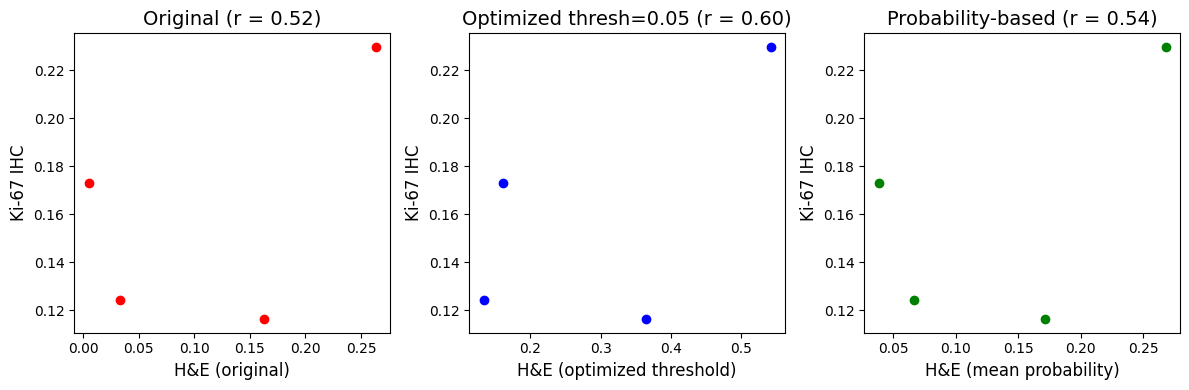


Summary:
  Original method:     r = 0.518
  Optimized threshold: r = 0.605
  Probability-based:   r = 0.536


In [15]:
# Recalculate with best parameters and plot comparison
HE_Dpos_optimized = []
for img_path in HE_list:
    pos_dense, _, _, _, _ = HE_calc_optimized(
        img_path, 
        thresh=best_params["thresh"], 
        mask_thresh=best_params["mask_thresh"]
    )
    HE_Dpos_optimized.append(pos_dense)

# Comparison plot: Original vs Optimized
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Original method
x_orig = np.array(HE_Dpos)
y = np.array(IHC_Dpos)
r_orig, p_orig = pearsonr(x_orig, y)
axes[0].scatter(x_orig, y, c="r", marker="o")
axes[0].set_title(f"Original (r = {r_orig:.2f})", fontsize=14)
axes[0].set_xlabel("H&E (original)", fontsize=12)
axes[0].set_ylabel("Ki-67 IHC", fontsize=12)

# Optimized thresholding
x_opt = np.array(HE_Dpos_optimized)
r_opt, p_opt = pearsonr(x_opt, y)
axes[1].scatter(x_opt, y, c="b", marker="o")
axes[1].set_title(f"Optimized thresh={best_params['thresh']:.2f} (r = {r_opt:.2f})", fontsize=14)
axes[1].set_xlabel("H&E (optimized threshold)", fontsize=12)
axes[1].set_ylabel("Ki-67 IHC", fontsize=12)

# Probability-based method
if len(HE_Dpos_probs) > 0:
    x_prob = np.array(HE_Dpos_probs)
    r_prob, p_prob = pearsonr(x_prob, y)
    axes[2].scatter(x_prob, y, c="g", marker="o")
    axes[2].set_title(f"Probability-based (r = {r_prob:.2f})", fontsize=14)
    axes[2].set_xlabel("H&E (mean probability)", fontsize=12)
    axes[2].set_ylabel("Ki-67 IHC", fontsize=12)

plt.tight_layout()
plt.savefig("slides/Correlation_D_pos_comparison.pdf", bbox_inches="tight", dpi=300)
plt.show()

print("\nSummary:")
print(f"  Original method:     r = {r_orig:.3f}")
print(f"  Optimized threshold: r = {r_opt:.3f}")
if len(HE_Dpos_probs) > 0:
    print(f"  Probability-based:   r = {r_prob:.3f}")

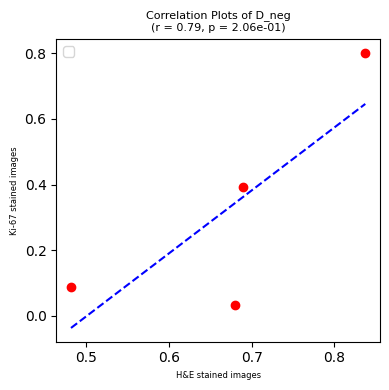

In [16]:
x = np.array(HE_Dneg)
y = np.array(IHC_Dneg)

r_val, p_val = pearsonr(x, y)

# Fit linear regression
slope, intercept = np.polyfit(x, y, 1)
fit_line = slope * x + intercept

fig, ax1 = plt.subplots(figsize=(4, 4))
ax1.set_title(f"Correlation Plots of D_neg\n(r = {r_val:.2f}, p = {p_val:.2e})", fontsize=8)
ax1.set_xlabel("H&E stained images", fontsize=6)
ax1.set_ylabel("Ki-67 stained images", fontsize=6)
ax1.scatter(x, y, c="r", marker="o")
ax1.plot(np.sort(x), slope * np.sort(x) + intercept, c="blue", linestyle="--",)
ax1.legend()
plt.tight_layout()
plt.savefig("slides/Correlation_D_neg.pdf", bbox_inches="tight", dpi=300)
plt.show()

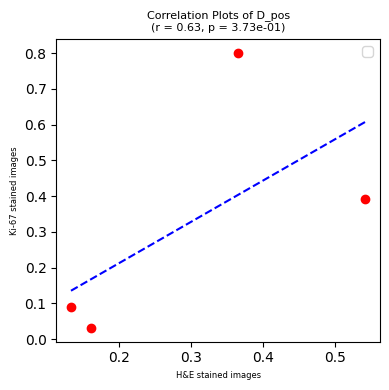

In [17]:
x_opt = np.array(HE_Dpos_optimized)
r_opt, p_opt = pearsonr(x_opt, y)

# Fit linear regression
slope, intercept = np.polyfit(x_opt, y, 1)
fit_line = slope * x_opt + intercept

fig, ax1 = plt.subplots(figsize=(4, 4))
ax1.set_title(f"Correlation Plots of D_pos\n(r = {r_opt:.2f}, p = {p_opt:.2e})", fontsize=8)
ax1.set_xlabel("H&E stained images", fontsize=6)
ax1.set_ylabel("Ki-67 stained images", fontsize=6)
ax1.scatter(x_opt, y, c="r", marker="o")
ax1.plot(np.sort(x_opt), slope * np.sort(x_opt) + intercept, c="blue", linestyle="--",)
ax1.legend()
plt.tight_layout()
plt.savefig("slides/Correlation_D_pos.pdf", bbox_inches="tight", dpi=300)
plt.show()

In [18]:
import scanpy as sc

In [19]:
# Read in
adata = sc.read_h5ad("data/adata_with_signatures_and_hotspots.h5ad")

### Correlate predicted Ki67 with G0/Quiescence scores in spatial data

In [41]:
# Slide-level analysis: correlate Ki67 prediction with mean quiescence score per slide
# Note: HE_Dpos_optimized was computed for slides in sorted order (slide_0, slide_4, slide_5, slide_7)

target_batches = ["0", "4", "5", "7"]

# Calculate mean quiescence score per slide (tumor cells only)
slide_data = []
for i, batch in enumerate(target_batches):
    batch_mask = (adata.obs["batch"] == batch) & (adata.obs["tumour_cells"] == 1)
    n_tumor_cells = batch_mask.sum()
    mean_quiescence = adata.obs.loc[batch_mask, "quiescence_score"].mean()
    ki67_density = HE_Dpos_optimized[i]  # Already computed in same slide order

    slide_data.append(
        {
            "batch": batch,
            "slide": f"slide_{batch}",
            "n_tumor_cells": n_tumor_cells,
            "mean_quiescence": mean_quiescence,
            "ki67_density": ki67_density,
        }
    )

slide_df = pd.DataFrame(slide_data)
print("Slide-Level Data:")
print(slide_df.to_string(index=False))

Slide-Level Data:
batch   slide  n_tumor_cells  mean_quiescence  ki67_density
    0 slide_0            953         1.388144      0.133399
    4 slide_4           3542        -0.235942      0.541919
    5 slide_5            831         3.128947      0.160594
    7 slide_7           3484         0.832208      0.364672


In [42]:
# Calculate correlation between slide-level Ki67 and quiescence
from scipy.stats import spearmanr

ki67_values = slide_df["ki67_density"].values
quiescence_values = slide_df["mean_quiescence"].values

# Pearson correlation
r_pearson, p_pearson = pearsonr(ki67_values, quiescence_values)

# Spearman correlation (rank-based, better for small n)
r_spearman, p_spearman = spearmanr(ki67_values, quiescence_values)

print("=" * 60)
print("SLIDE-LEVEL CORRELATION: Ki67 Prediction vs Quiescence Score")
print("=" * 60)
print(f"\nNumber of slides: {len(slide_df)}")
print(f"\nPearson correlation:  r = {r_pearson:.4f}, p = {p_pearson:.4f}")
print(f"Spearman correlation: rho = {r_spearman:.4f}, p = {p_spearman:.4f}")
print("\nNote: With n=4, statistical power is limited. Focus on the direction")
print("      of correlation rather than p-values.")

SLIDE-LEVEL CORRELATION: Ki67 Prediction vs Quiescence Score

Number of slides: 4

Pearson correlation:  r = -0.8318, p = 0.1682
Spearman correlation: rho = -0.8000, p = 0.2000

Note: With n=4, statistical power is limited. Focus on the direction
      of correlation rather than p-values.


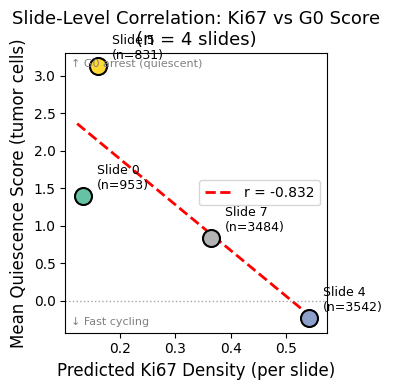

In [45]:
# Visualization: Slide-level correlation plot
fig, ax = plt.subplots(figsize=(4, 4))

# Scatter plot with batch labels
colors = plt.cm.Set2(np.linspace(0, 1, len(target_batches)))
for i, row in slide_df.iterrows():
    ax.scatter(
        row["ki67_density"],
        row["mean_quiescence"],
        s=150,
        c=[colors[i]],
        edgecolors="k",
        linewidth=1.5,
        zorder=3,
    )
    ax.annotate(
        f"Slide {row['batch']}\n(n={row['n_tumor_cells']})",
        (row["ki67_density"], row["mean_quiescence"]),
        xytext=(10, 5),
        textcoords="offset points",
        fontsize=9,
    )

# Regression line
slope, intercept = np.polyfit(ki67_values, quiescence_values, 1)
x_line = np.linspace(ki67_values.min() - 0.01, ki67_values.max() + 0.01, 100)
ax.plot(
    x_line,
    slope * x_line + intercept,
    "r--",
    linewidth=2,
    label=f"r = {r_pearson:.3f}",
    zorder=2,
)

ax.set_xlabel("Predicted Ki67 Density (per slide)", fontsize=12)
ax.set_ylabel("Mean Quiescence Score (tumor cells)", fontsize=12)
ax.set_title(
    f"Slide-Level Correlation: Ki67 vs G0 Score\n(n = {len(slide_df)} slides)",
    fontsize=13,
)
ax.legend(loc="best", fontsize=10)
ax.axhline(y=0, color="gray", linestyle=":", linewidth=1, alpha=0.7)

# Add annotation for quiescence interpretation
ax.text(
    0.02,
    0.98,
    "↑ G0 arrest (quiescent)",
    transform=ax.transAxes,
    fontsize=8,
    va="top",
    ha="left",
    color="gray",
)
ax.text(
    0.02,
    0.02,
    "↓ Fast cycling",
    transform=ax.transAxes,
    fontsize=8,
    va="bottom",
    ha="left",
    color="gray",
)

plt.tight_layout()
plt.savefig(
    "slides/Ki67_Quiescence_SlideLevel_Correlation.pdf", bbox_inches="tight", dpi=300
)
plt.show()


In [44]:
# Summary table
print("=" * 70)
print("SUMMARY: Slide-Level Ki67 Prediction vs Quiescence Score")
print("=" * 70)
print("\nSlide-Level Data:")
print(slide_df.to_string(index=False))
print("\n" + "-" * 70)
print("Correlation Results:")
print(f"  Pearson r:  {r_pearson:.4f} (p = {p_pearson:.4f})")
print(f"  Spearman ρ: {r_spearman:.4f} (p = {p_spearman:.4f})")
print("-" * 70)

# Score interpretation
print("\nScore Interpretation:")
print("  • Quiescence Score > 0: G0 arrest (quiescent, non-cycling)")
print("  • Quiescence Score < 0: Fast cycling (proliferating)")
print("  • Ki67 Density: Higher = more predicted proliferation")

# Correlation interpretation
print("\nCorrelation Interpretation:")
if r_pearson < -0.3:
    print(f"  ✓ NEGATIVE correlation (r = {r_pearson:.3f}):")
    print("    Slides with higher predicted Ki67 have lower mean quiescence scores")
    print("    (i.e., more fast-cycling tumor cells).")
    print("    This is biologically expected and supports the Ki67 prediction model.")
elif r_pearson > 0.3:
    print(f"  ⚠ POSITIVE correlation (r = {r_pearson:.3f}):")
    print("    Slides with higher predicted Ki67 have higher mean quiescence scores")
    print("    (i.e., more G0-arrested tumor cells).")
    print(
        "    This is unexpected - may indicate model limitations or biological complexity."
    )
else:
    print(f"  ○ WEAK correlation (r = {r_pearson:.3f}):")
    print("    No strong relationship at slide level between Ki67 prediction")
    print("    and transcriptome-based quiescence scoring.")

print("\n" + "=" * 70)


SUMMARY: Slide-Level Ki67 Prediction vs Quiescence Score

Slide-Level Data:
batch   slide  n_tumor_cells  mean_quiescence  ki67_density
    0 slide_0            953         1.388144      0.133399
    4 slide_4           3542        -0.235942      0.541919
    5 slide_5            831         3.128947      0.160594
    7 slide_7           3484         0.832208      0.364672

----------------------------------------------------------------------
Correlation Results:
  Pearson r:  -0.8318 (p = 0.1682)
  Spearman ρ: -0.8000 (p = 0.2000)
----------------------------------------------------------------------

Score Interpretation:
  • Quiescence Score > 0: G0 arrest (quiescent, non-cycling)
  • Quiescence Score < 0: Fast cycling (proliferating)
  • Ki67 Density: Higher = more predicted proliferation

Correlation Interpretation:
  ✓ NEGATIVE correlation (r = -0.832):
    Slides with higher predicted Ki67 have lower mean quiescence scores
    (i.e., more fast-cycling tumor cells).
    This is 